In [13]:
# import libraries
import qiskit
from qiskit import QuantumCircuit,transpile

from qiskit_aer import AerSimulator, StatevectorSimulator
from qiskit.circuit.library import QFT
from qiskit.circuit import Parameter

from qiskit_aer.primitives import Sampler as AerSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit.visualization import plot_histogram, plot_bloch_multivector


import matplotlib.pyplot as plt
import numpy as np 
from math import gcd 
from numpy.random import randint 
import pandas as pd 
from scipy.optimize import minimize

In [21]:
## C = 1, A, B = max(v_i,j)

def knapsack_hamiltonian(weights, values, capacities, gamma):
    weights = np.array(weights); values = np.array(values); capacities = np.array(capacities)

    maxv = 2 * np.max(values)
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 
    s = np.int64(np.floor(np.log2(capacities)) + 1) # number of slack bits 
    total_s = np.sum(s)

    qc = QuantumCircuit(n*m + total_s*m)

    for i in range(m): 
        b = np.array([_ for _ in range(s[i])])

        for j in range(n):
            # qubit i, j corresponds to i*n + j 
            # objective term 
            qc.rz(-gamma*values[i], i*n + j)

            # occupation term 1 
            qc.rz(maxv * gamma*(1-2*m), i*n + j)

            # all capacity terms 
            cap_linear_ij = -np.sum(weights*weights[j])/2 - np.sum(weights[j]*2**b[i])/2 + weights[j]*capacities[i]
            qc.rz(maxv * 2*cap_linear_ij*gamma, i*n + j)

            for jp in range(j+1, n): 
                if j != jp: 
                    qc.rzz(maxv * gamma*weights[j]*weights[jp]/2, i*n + j, i*n + jp)

            for ip in range(i+1, m): 
                # occupation term 2 
                if i != ip: 
                    qc.rzz(maxv * gamma/2, i*n + j, ip*n + j)

            for b_val in b: 
                qc.rzz(maxv * gamma*weights[j]*2**b_val, i*n + j, n*m + i*s[i] + b_val)
        
        for (i_b, b_val) in enumerate(b): 
            cap_linear_ib = -np.sum(2**(b_val+b[i]))/2 - np.sum(weights*2**b_val)/2 + 2**b_val*capacities[i]
            qc.rz(maxv * 2*cap_linear_ib*gamma, n*m + i*s[i] + b_val)

            for i_bp in range(i_b, len(b)):
                bp_val = b[i_bp]
                if b_val != bp_val: 
                    qc.rzz(maxv * 2**(b_val + bp_val)/2, n*m + i*s[i] + b_val, n*m + i*s[i] + bp_val)

    return qc 

In [22]:
def mixing_hamiltonian(N, beta): 
    qc = QuantumCircuit(N)
    
    for i in range(N): 
        qc.rx(2*beta, i)

    return qc 

In [23]:
def full_knapsack_circuit(weights, values, capacities, p=1): 
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 
    s = np.int64(np.floor(np.log2(capacities)) + 1) # number of slack bits 
    total_s = np.sum(s)
    N = n*m + total_s

    qc = QuantumCircuit(N, n*m)
    qc.h(range(N))

    for _ in range(p): 
        qc.compose(knapsack_hamiltonian(weights, values, capacities, Parameter(f"γ{_}")), inplace=True)
        qc.barrier()
        qc.compose(mixing_hamiltonian(N, Parameter(f"β{_}")), inplace=True)
        qc.barrier()

    qc.measure(range(n*m), range(n*m))
    return qc 

In [24]:
def objective(params, weights, values, capacities, p, sampler, shots=10000): 
    n = len(weights) # number of items 
    m = len(capacities) # number of knapsacks 

    qc = full_knapsack_circuit(weights, values, capacities, p)
    job = sampler.run([qc], [params], shots=shots)
    counts = job.result().quasi_dists[0].binary_probabilities()

    # compute expected value 
    expected = 0 
    for bitstring, prob in counts.items(): 
        # get all the items that were chosen 
        x = np.array([int(b) for b in reversed(bitstring)])

        assert len(x) == n*m, f"expected {n*m} bits, got {len(x)}"

        x = x.reshape(m, n)
        if all(np.dot(x[i], weights) <= capacities[i] for i in range(m)): 
            # i.e., if feasible 
            total_value = sum(x[i][j] * values[j] for i in range(m) for j in range(n))
            expected += prob * total_value
    
    return -expected # minimize -expected to maximize knapsack value 

In [67]:
backend = AerSimulator()
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

sampler = AerSampler()

In [92]:
capacities = [7]
p = 2 # number of layers 
# 10 = 1010
weights = [1, 1, 6, 3]
values = [1, 3, 8, 10]
n = len(weights) # number of items 
m = len(capacities) # number of knapsacks 


In [93]:
result = minimize(objective, x0=np.random.uniform(0, np.pi, 2*p), args=(weights, values, capacities, p, sampler, 4096), method='COBYLA')

# now run with optimized params
best_params = result.x

In [94]:
best_params

array([2.92730161, 0.86827017, 2.39990688, 1.03974353])

SamplerResult(quasi_dists=[{9: 0.0322, 8: 0.1362, 0: 0.0648, 12: 0.0623, 3: 0.0424, 4: 0.1315, 13: 0.031, 5: 0.0364, 11: 0.1526, 1: 0.0378, 7: 0.0988, 2: 0.0331, 6: 0.0404, 10: 0.026, 14: 0.0287, 15: 0.0458}], metadata=[{'shots': 10000, 'simulator_metadata': {'batched_shots_optimization': False, 'required_memory_mb': 1, 'method': 'statevector', 'active_input_qubits': [0, 1, 2, 3, 4, 5, 6], 'device': 'CPU', 'remapped_qubits': False, 'num_qubits': 7, 'num_clbits': 4, 'time_taken': 0.0259714, 'sample_measure_time': 0.0018434, 'input_qubit_map': [[0, 0], [1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6]], 'max_memory_mb': 16068, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 12, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': True, 'threshold': 14, 'max_fused_qubits': 5, 'applied': False}}}])
quasidist {'1001': 0.0322, '1000': 0.1362, '0000': 0.0648, '1100': 0.0623, '0011': 0.0424, '0100': 0.1315, '1101': 0.031, '0101': 0

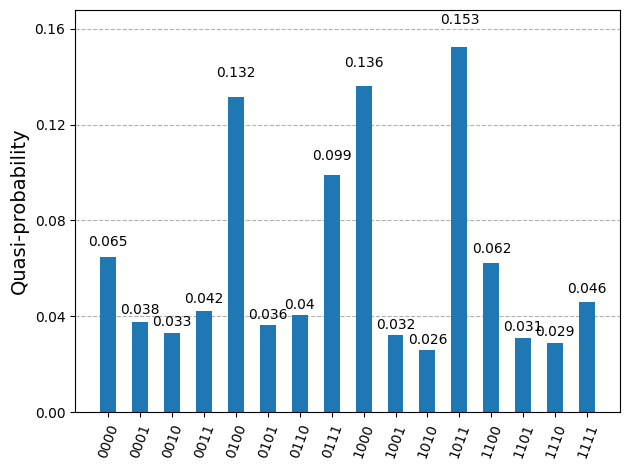

In [95]:
mycirc = full_knapsack_circuit(weights, values, capacities, p)

circ = [mycirc]
param_sets = [best_params]

job_sim = sampler.run(circ, param_sets, shots=10000)
print(job_sim.result())

quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()
print("quasidist", quasi_dists)
plot_histogram(quasi_dists)


In [100]:
# check feasible out of most probable
sorted_results = sorted(quasi_dists.items(), key=lambda x: x[1], reverse=True)
soln = []

for bitstring, prob in sorted_results: 
    # get all the items that were chosen 
    x = np.array([int(b) for b in reversed(bitstring)])

    assert len(x) == n*m, f"expected {n*m} bits, got {len(x)}"

    x = x.reshape(m, n)
    if all(np.dot(x[i], weights) <= capacities[i] for i in range(m)): 
        soln = x
        break 
print(soln)


[[1 1 0 1]]
